# global_cancer_patients_2015_2024 — Limpieza de datos y comparación de modelos

**Dataset:** [global_cancer_patients_2015_2024](https://www.kaggle.com/datasets/zahidmughal2343/global-cancer-patients-2015-2024)  
**Descripción:** Datos de pacientes diagnosticados con cáncer entre 2015 a 2024. Integra factores clave en el desarrollo de enfemerdades oncológicas.
- 50,000 pacientes
- Rango de edades entre 20 a 90 años
- Incluye factores sociales y médicos
- Data limpia y sin sezgos

---

**Librerías**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

**Cargar dataset**

In [ ]:
import kagglehub

# Descargar el dataset
path = kagglehub.dataset_download("zahidmughal2343/global-cancer-patients-2015-2024")
path = os.path.join(path, "global_cancer_patients_2015_2024.csv")
print("Ruta de archivo:", path)

100%|██████████| 1.20M/1.20M [00:00<00:00, 1.60MB/s]

Extracting files...
Ruta de archivo: /root/.cache/kagglehub/datasets/zahidmughal2343/global-cancer-patients-2015-2024/versions/1/global_cancer_patients_2015_2024.csv


In [ ]:
# Análisis incial del dataset
df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

#**Técnicas de limpieza**

**Valores nulos**

No hay valores nulos que tratar.

In [ ]:
nulos_df = pd.DataFrame(df.isnull().sum(), columns=['Cantidad de nulos'])
nulos_df

,Cantidad de nulos
Patient_ID,0
Age,0
Gender,0
Country_Region,0
Year,0
Genetic_Risk,0
Air_Pollution,0
Alcohol_Use,0
Smoking,0
Obesity_Level,0


**Tratamiento de outliers**

En el análisis EDA se identificó que únicamente la variable "Target_Severity_Score" posee valores atípicos. Estos valores representan casos extremos que requieren de atención inmediata o de muy bajo riesgo.

Se procede a realizar el tratamiento de outliers con el método de las tres varianzas.

Valor mínimo de Target_Severity_Score:  0.9
Valor máximo de Target_Severity_Score:  9.16



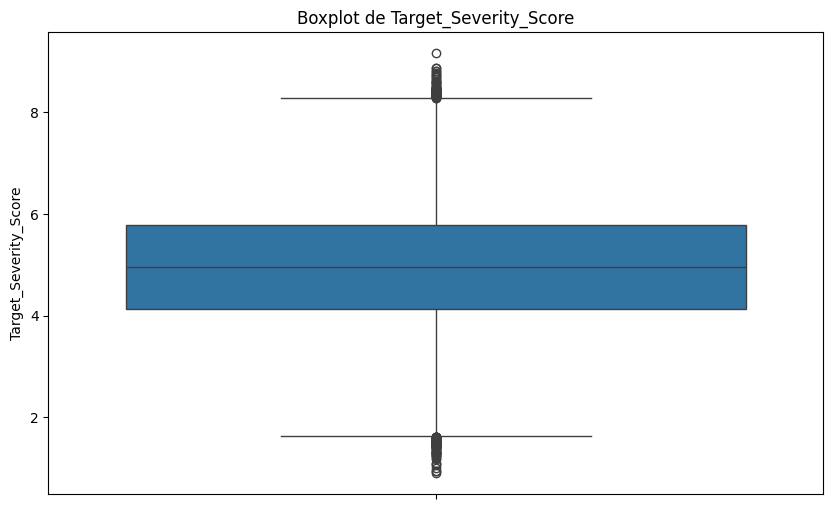

In [ ]:
print("Valor mínimo de Target_Severity_Score: ", df["Target_Severity_Score"].min())
print("Valor máximo de Target_Severity_Score: ", df["Target_Severity_Score"].max())
print()
plt.figure(figsize=(10, 6))
sns.boxplot(data=df["Target_Severity_Score"])
plt.title("Boxplot de Target_Severity_Score")
plt.show()

In [ ]:
up_limit = df["Target_Severity_Score"].mean() + 3*df["Target_Severity_Score"].std()
down_limit = df["Target_Severity_Score"].mean() - 3*df["Target_Severity_Score"].std()
print("Mas alto permitido: ", up_limit)
print("Mas bajo permitido: ", down_limit)

Mas alto permitido:  8.550237740252001
Mas bajo permitido:  1.3521770597479974


In [ ]:
df["Target_Severity_Score"] = np.where(
    # Si un valor está por encima de UP, se convierte a UP
    df["Target_Severity_Score"] > up_limit,
    up_limit,
    np.where(
        # Si está por debajo de DOWN, se convierte a DOWN
        df["Target_Severity_Score"] < down_limit,
        down_limit,
        # Si no está fuera de rango, se deja igual
        df["Target_Severity_Score"]
    )
)

Valor mínimo de Target_Severity_Score:  1.3521770597479974
Valor máximo de Target_Severity_Score:  8.550237740252001



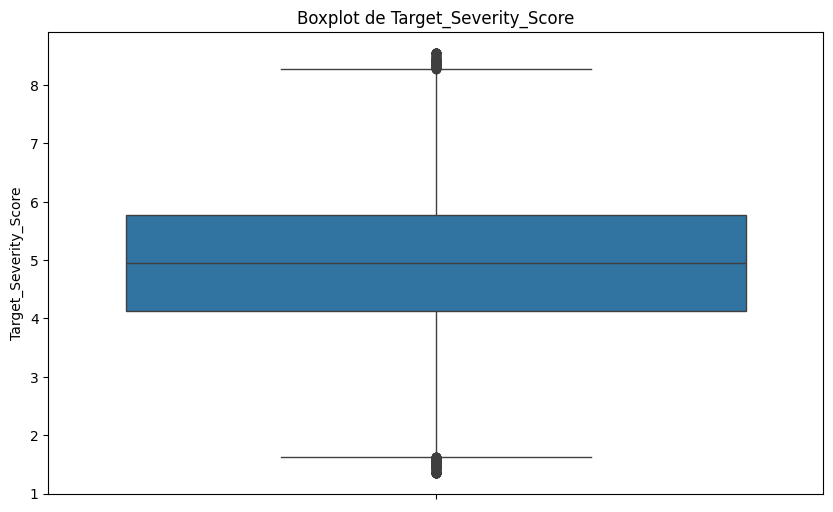

In [ ]:
# Volver a revisar los valores atípicos
print("Valor mínimo de Target_Severity_Score: ", df["Target_Severity_Score"].min())
print("Valor máximo de Target_Severity_Score: ", df["Target_Severity_Score"].max())
print()
plt.figure(figsize=(10, 6))
sns.boxplot(data=df["Target_Severity_Score"])
plt.title("Boxplot de Target_Severity_Score")
plt.show()

___

**Preparación de los datos para el modelo**

In [ ]:
#Eliminar variable identificadora
df = df.drop(columns=["Patient_ID"])

In [ ]:
print(df['Cancer_Stage'].unique())

['Stage III' 'Stage 0' 'Stage II' 'Stage I' 'Stage IV']


In [ ]:
# Conversión de columnas categóricas a numéricas

# Tratamiento de Cancer_Stage
stage_map = {
    "Stage 0":1,
    "Stage I":2,
    "Stage II":3,
    "Stage III":4,
    "Stage IV":5
}
df["Cancer_Stage"] = df["Cancer_Stage"].map(stage_map)

# Crea columnas por cada valor unico en las variables categóricas
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df["Severity_Class"] = pd.cut(
    df["Target_Severity_Score"],
    bins=[0, 3, 7, 10],
    labels=[0,1,2]
)
# 0: bajo , 1: medio, 2: alto

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      50000 non-null  int64   
 1   Year                     50000 non-null  int64   
 2   Genetic_Risk             50000 non-null  float64 
 3   Air_Pollution            50000 non-null  float64 
 4   Alcohol_Use              50000 non-null  float64 
 5   Smoking                  50000 non-null  float64 
 6   Obesity_Level            50000 non-null  float64 
 7   Cancer_Stage             50000 non-null  int64   
 8   Treatment_Cost_USD       50000 non-null  float64 
 9   Survival_Years           50000 non-null  float64 
 10  Target_Severity_Score    50000 non-null  float64 
 11  Gender_Male              50000 non-null  bool    
 12  Gender_Other             50000 non-null  bool    
 13  Country_Region_Brazil    50000 non-null  bool    
 14  Countr

**Seleccionar los conjuntos de datos**

In [ ]:
X = df.drop(columns=["Target_Severity_Score", "Severity_Class"])

y = df["Severity_Class"]

**Escalar los valores**

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

**Separar datos de entrenamiento y prueba**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=42)



---



**Entrenamiento - MODELO BIOINSPIRADO**

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(5,3,7,2), max_iter=1000, random_state = 1)

In [ ]:
mlp.fit(X_train, y_train) #va a predecir en base a X y calibrar con Y

MLPClassifier(hidden_layer_sizes=(5, 3, 7, 2), max_iter=1000, random_state=1)

In [ ]:
y_pred = mlp.predict(X_test) #predicciones

**Resultados**

Precision: 0.9944
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       778
           1       1.00      1.00      1.00     13568
           2       0.98      0.97      0.97       654

    accuracy                           0.99     15000
   macro avg       0.97      0.99      0.98     15000
weighted avg       0.99      0.99      0.99     15000




<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

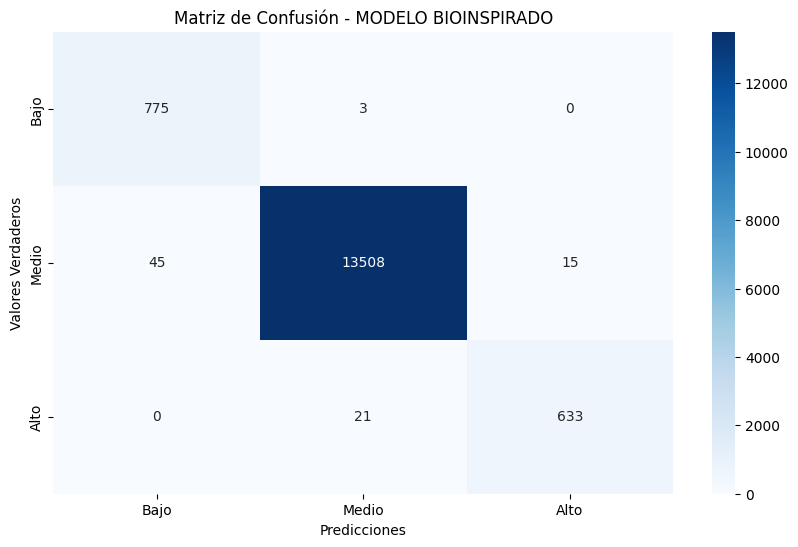

In [ ]:
#evaluacion
print("Precision:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print()
#evaluacion
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión - MODELO BIOINSPIRADO')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt



---






**Entrenamiento - MODELO RANDOM FOREST**

In [ ]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

# Crear modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42 # reproduccion
)

# entrenamiento
rf_model.fit(X_train, y_train)

# predicciones
y_pred_rf = rf_model.predict(X_test)

**Resultados**

Precision: 0.9399333333333333
              precision    recall  f1-score   support

           0       0.99      0.42      0.59       778
           1       0.94      1.00      0.97     13568
           2       1.00      0.32      0.48       654

    accuracy                           0.94     15000
   macro avg       0.98      0.58      0.68     15000
weighted avg       0.94      0.94      0.93     15000




<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

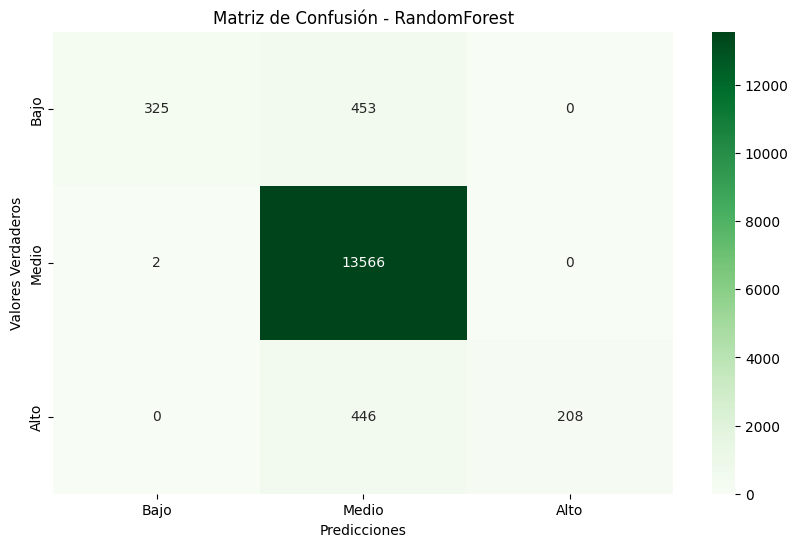

In [ ]:
#evaluacion
print("Precision:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print()
# imprimir matriz de correlacion
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Greens", xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión - RandomForest')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt



---







**Entrenamiento - MODELO XGBOOST**

In [ ]:
# XGBOOST
from xgboost import XGBClassifier

# Crear modelo
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42 # reproduccion
)

# entrenmiento
xgb_model.fit(X_train, y_train)

# predicciones
y_pred_xgb = xgb_model.predict(X_test)

**Resultados**

Precision: 0.9770666666666666
              precision    recall  f1-score   support

           0       0.99      0.80      0.88       778
           1       0.98      1.00      0.99     13568
           2       0.97      0.75      0.85       654

    accuracy                           0.98     15000
   macro avg       0.98      0.85      0.91     15000
weighted avg       0.98      0.98      0.98     15000




<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

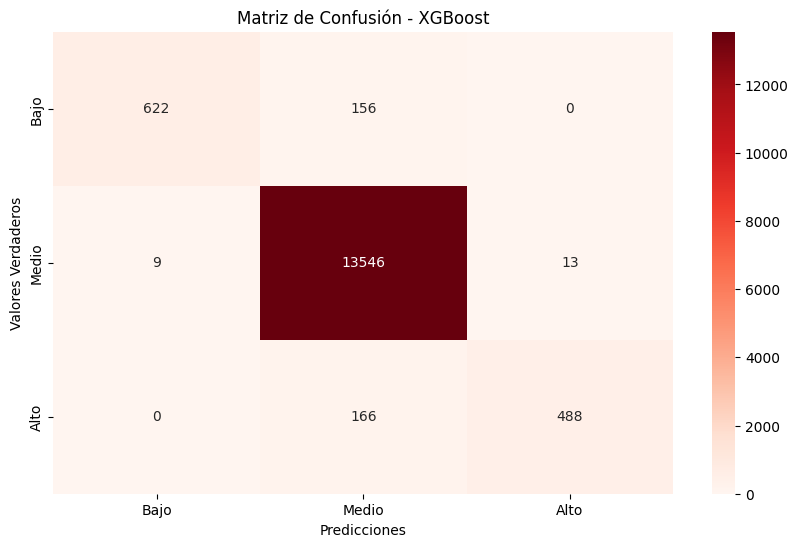

In [ ]:
#evaluacion
print("Precision:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print()
# imprimir matriz de correlacion
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(10, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap="Reds", xticklabels=['Bajo', 'Medio', 'Alto'], yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión - XGBoost')
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt